<a href="https://colab.research.google.com/github/oyueo-mm/DBSCAN_Entry/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터 불러오기

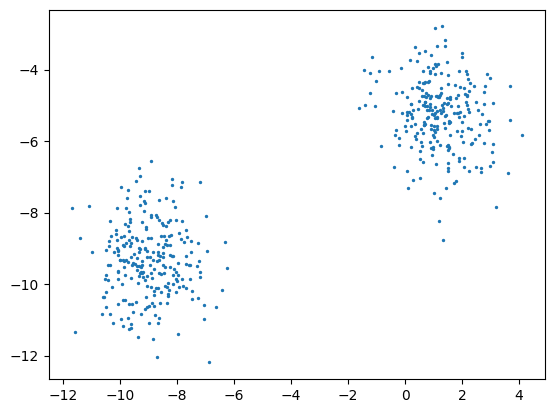

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

data = make_blobs(n_samples=500, centers=2)[0]
plt.scatter(data[:, 0], data[:, 1], s=2)

In [ ]:
type(data)

numpy.ndarray

In [ ]:
len(data)

500

# 핵심 대상 집합 만들기

In [ ]:
episilon = 0.7
Min_pts = 3

mains = []
mini_area = []


for i, D in enumerate(data):
  for j, d in enumerate(data):
    if i != j:
      if np.linalg.norm(D - d) < episilon:
        mini_area.append(j)
  if len(mini_area) > Min_pts:
    mains.append(i)
  mini_area = []

# 클러스터 생성

In [ ]:
def get_neighbor_idx(main_index, data = data, eps = episilon):
  neightbors_idx = []
  for i, d in enumerate(data):
    # 자기 자신이 아니면서 클러스터가 빈 데이터만 구하기
    if (main_index != i) & (cluster[i] == -1):
      if np.linalg.norm(data[main_index] - d)  < eps:
        neightbors_idx.append(i)
  return neightbors_idx

In [ ]:
from collections import deque

cluster = [-1] * len(data)
k = 0

while mains:
  # 처음 핵심 대상에서 하나 뽑기
  idx = np.random.choice(mains)
  mains.remove(idx)
  neighbors_idx = get_neighbor_idx(idx)
  if len(neighbors_idx) < Min_pts:
      continue
  cluster[idx] = k
  # Q에 핵심 대상 집합의 이웃의 인덱스를 넣고 검사 시작
  Q = deque(neighbors_idx)
  while Q:
    D = Q.popleft()
    # 아직 클러스터가 없는 데이터만 검사
    if cluster[D] == -1:
      cluster[D] = k
      neighbors_idx = get_neighbor_idx(D)
      if len(neighbors_idx) >= Min_pts:
        # 근데 D가 핵심대상이 된다면 Q에 다시 집어넣기
        for i in neighbors_idx:
          Q.append(i)
  k += 1

# 시각화

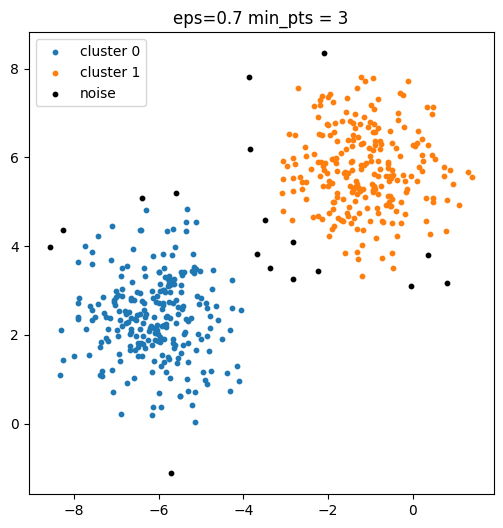

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cluster_np = np.array(cluster)

unique_clusters = set(cluster_np)

plt.figure(figsize=(6,6))

for k in unique_clusters:
    if k == -1:
        color = 'black'
        label = 'noise'
    else:
        color = None
        label = f'cluster {k}'

    plt.scatter(data[cluster_np == k, 0], data[cluster_np == k, 1], s=10, c=color, label=label)

plt.legend()
plt.title(f"eps={episilon} min_pts = {Min_pts}")
plt.show()